# Predicting Remaining Useful Life of Turbofan Engines

**Student Name:** Channaveer

**Internship:** Data Science and Machine Learning Internship  
**Dataset:** NASA C-MAPSS Turbofan Dataset  
**Model Used:** Stacked LSTM

## Project Goal
The goal of this project is to predict the Remaining Useful Life (RUL) of turbofan engines using sensor data.
Using time-series measurements from multiple sensors, we train a deep learning model to estimate how many cycles remain before an engine fails.

# Dataset Description

The dataset used in this project is the NASA turbofan engine dataset.

Each row in the dataset represents one operational cycle of an engine.
The dataset contains the following information:

- Engine ID (unit number)
- Cycle number
- 3 operational settings
- 21 sensor measurements

In the training data, each engine runs until failure.
In the test data, the engines stop before failure and the task is to predict the remaining cycles.

# Import Libraries

First, we import the required Python libraries for data processing,
machine learning, and deep learning.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Load Training Data

Here we load the training dataset and assign column names so the data is easier to understand and work with.

In [ ]:
train_path = '/content/drive/MyDrive/Turbofan_RUL_Project/Turbofan engine/train_FD001.txt'

train_df = pd.read_csv(train_path, sep=' ', header=None)
train_df = train_df.dropna(axis=1)

columns = ['unit_number', 'cycle'] + \
          [f'operational_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

train_df.columns = columns

print("Train shape:", train_df.shape)

Train shape: (20631, 26)


In [ ]:
max_cycle_df = train_df.groupby('unit_number')['cycle'].max().reset_index()
max_cycle_df.columns = ['unit_number', 'max_cycle']

train_df = train_df.merge(max_cycle_df, on='unit_number')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Cap RUL
train_df['RUL'] = train_df['RUL'].clip(upper=125)

print("RUL created")

RUL created


# Data Preprocessing

Some sensors in the dataset have constant values for all rows.
Since they do not provide useful information for prediction, we remove them from the dataset.

In [ ]:
constant_columns = [
    'operational_setting_3',
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

train_df = train_df.drop(columns=constant_columns)

In [ ]:
feature_cols = train_df.drop(columns=['unit_number', 'cycle', 'max_cycle', 'RUL']).columns

feature_cols = train_df.drop(columns=['unit_number','cycle','max_cycle','RUL']).columns

scaler = MinMaxScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
sequence_length = 40

def create_sequences(df, seq_length):

    X = []
    y = []

    for engine in df['unit_number'].unique():

        engine_data = df[df['unit_number']==engine]

        features = engine_data[feature_cols].values
        target = engine_data['RUL'].values

        for i in range(len(engine_data)-seq_length):

            X.append(features[i:i+seq_length])
            y.append(target[i+seq_length])

    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(train_df, sequence_length)

print("Sequence shape:", X_seq.shape)

Sequence shape: (16631, 40, 17)


# Train Validation Split

The engines are split into training and validation sets based on engine IDs.
This ensures that data from the same engine does not appear in both sets.

In [ ]:
engine_ids = train_df['unit_number'].unique()

np.random.seed(42)
np.random.shuffle(engine_ids)

split = int(len(engine_ids)*0.8)

train_engines = engine_ids[:split]
val_engines = engine_ids[split:]

train_mask=[]
val_mask=[]

for engine in train_df['unit_number'].unique():

    length = len(train_df[train_df['unit_number']==engine])
    seq_count = length - sequence_length

    if engine in train_engines:
        train_mask.extend([True]*seq_count)
        val_mask.extend([False]*seq_count)

    else:
        train_mask.extend([False]*seq_count)
        val_mask.extend([True]*seq_count)

train_mask=np.array(train_mask)
val_mask=np.array(val_mask)

X_train_seq = X_seq[train_mask]
y_train_seq = y_seq[train_mask]

X_val_seq = X_seq[val_mask]
y_val_seq = y_seq[val_mask]

print("Train:",X_train_seq.shape)
print("Val:",X_val_seq.shape)

Train: (13140, 40, 17)
Val: (3491, 40, 17)


# LSTM Model

In this project we use a stacked LSTM model.
LSTM works well for time-series data because it can learn patterns over time.

The model contains two LSTM layers followed by dense layers to predict the RUL.

In [ ]:
model = Sequential([

    LSTM(128, return_sequences=True,
         input_shape=(sequence_length,len(feature_cols))),

    Dropout(0.3),

    LSTM(64),

    Dropout(0.3),

    Dense(32,activation='relu'),

    Dense(1)

])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 40, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,273 (493.25 KB)

 Trainable params: 126,273 (493.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(X_val_seq,y_val_seq),

    epochs=50,
    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5764.6001 - mae: 64.6844 - val_loss: 2324.1641 - val_mae: 42.2824
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1971.7220 - mae: 39.0915 - val_loss: 1757.6860 - val_mae: 37.4396
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1771.8134 - mae: 37.1659 - val_loss: 1751.2782 - val_mae: 37.3230
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1775.5599 - mae: 37.1071 - val_loss: 1760.8750 - val_mae: 37.4896
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1794.2074 - mae: 37.3936 - val_loss: 1755.3143 - val_mae: 37.3994
Epoch 6/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1777.9812 - mae: 37.1532 - val_loss: 1751.8007 - val_mae: 37.3335
Epoch 7/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1775.5880 - mae: 37.1211 - val_loss: 1748.7845 - val_mae: 37.2672
Epoch 8/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1778.7014 - mae: 37.1539 - val_loss: 1753.3916 - v

In [ ]:
test_path = '/content/drive/MyDrive/Turbofan_RUL_Project/Turbofan engine/test_FD001.txt'

test_df = pd.read_csv(test_path, sep=' ', header=None)

test_df = test_df.dropna(axis=1)

test_df.columns = columns

test_df = test_df.drop(columns=constant_columns)

test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [ ]:
def create_test_sequences(df, seq_length):

    X_test = []

    for engine in df['unit_number'].unique():

        engine_data = df[df['unit_number'] == engine]
        features = engine_data[feature_cols].values

        if len(features) < seq_length:

            padding = np.zeros((seq_length - len(features), features.shape[1]))
            padded = np.vstack((padding, features))
            X_test.append(padded)

        else:
            X_test.append(features[-seq_length:])

    return np.array(X_test)

In [ ]:
X_test_seq = create_test_sequences(test_df, sequence_length)

print(X_test_seq.shape)

(100, 40, 17)


In [ ]:
rul_path='/content/drive/MyDrive/Turbofan_RUL_Project/Turbofan engine/RUL_FD001.txt'

true_rul = pd.read_csv(rul_path,header=None).values.flatten()

true_rul_filtered = true_rul[np.array(used_engines) - 1]

# Model Evaluation

To evaluate the model, we use the following metrics:

RMSE – Root Mean Squared Error  
MAE – Mean Absolute Error  
R² – Coefficient of determination

In [ ]:
y_test_pred = model.predict(X_test_seq)

rmse_test = np.sqrt(mean_squared_error(true_rul, y_test_pred))
mae_test = mean_absolute_error(true_rul, y_test_pred)
r2_test = r2_score(true_rul, y_test_pred)

print("Final Test RMSE:", rmse_test)
print("Final Test MAE :", mae_test)
print("Final Test R2  :", r2_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Final Test RMSE: 14.46344859343178
Final Test MAE : 10.644037246704102
Final Test R2  : 0.8788609504699707


## Making Predictions for New Engine Data

After training the model, we can use it to predict the Remaining Useful Life of new engines based on the latest sensor measurements.

In [ ]:
def predict_rul(engine_df):

    scaled = scaler.transform(engine_df)

    # if cycles < sequence_length, pad with first row
    if len(scaled) < sequence_length:

        padding = np.repeat(
            scaled[0].reshape(1,-1),
            sequence_length - len(scaled),
            axis=0
        )

        scaled = np.vstack((padding, scaled))

    # take last sequence
    seq = scaled[-sequence_length:]

    seq = seq.reshape(1, sequence_length, len(feature_cols))

    prediction = model.predict(seq)

    return prediction[0][0]

In [ ]:
engine_example = test_df[test_df['unit_number']==1]

prediction = predict_rul(engine_example[feature_cols])

print(f"Predicted Remaining Useful Life: {round(prediction)} cycles")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted Remaining Useful Life: 1 cycles


## Example Predictions

Below are example predictions from the trained model for several engines in the test dataset.

The predicted Remaining Useful Life (RUL) values are compared with the true RUL values.

In [ ]:
for i in range(5):
    print(f"Engine {i+1}")
    print("Predicted RUL:", round(y_test_pred[i][0]), "cycles")
    print("True RUL:", true_rul_filtered[i])
    print()

Engine 1
Predicted RUL: 101 cycles
True RUL: 98

Engine 2
Predicted RUL: 111 cycles
True RUL: 69

Engine 3
Predicted RUL: 59 cycles
True RUL: 82

Engine 4
Predicted RUL: 93 cycles
True RUL: 91

Engine 5
Predicted RUL: 83 cycles
True RUL: 93



#Visualization



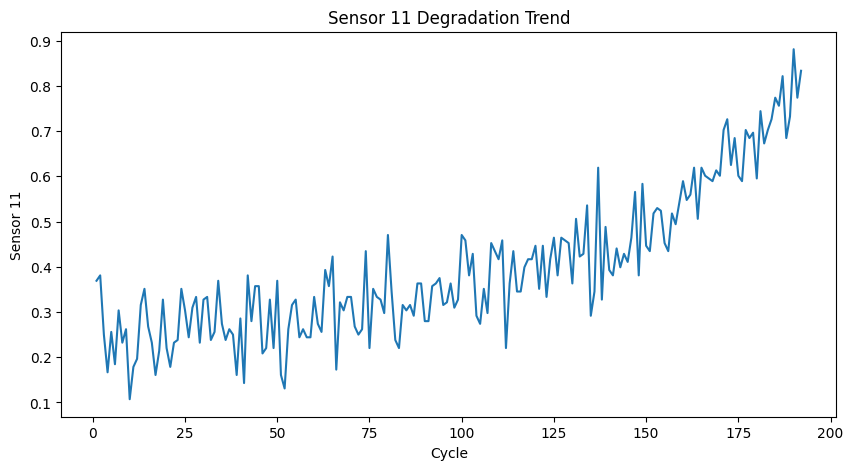

In [ ]:
import matplotlib.pyplot as plt

engine1 = train_df[train_df['unit_number']==1]

plt.figure(figsize=(10,5))
plt.plot(engine1['cycle'], engine1['sensor_11'])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Degradation Trend")
plt.show()

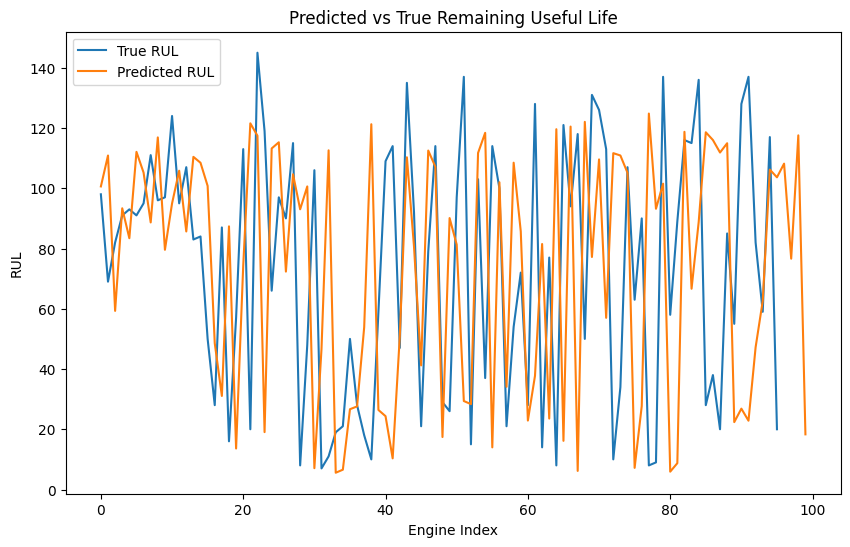

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(true_rul_filtered, label="True RUL")
plt.plot(y_test_pred, label="Predicted RUL")

plt.xlabel("Engine Index")
plt.ylabel("RUL")
plt.title("Predicted vs True Remaining Useful Life")

plt.legend()
plt.show()

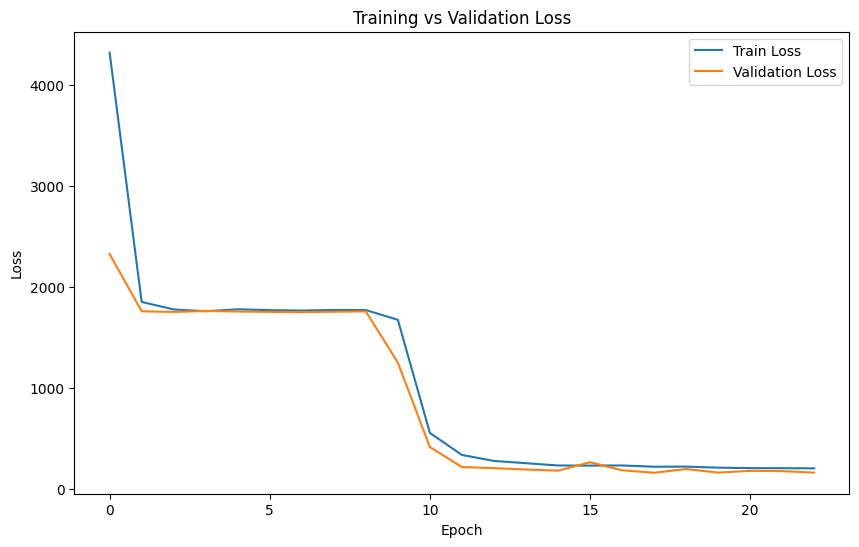

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/Turbofan_RUL_Project/turbofan_rul_lstm_model.h5')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
model.save('/content/drive/MyDrive/Turbofan_RUL_Project/turbofan_rul_lstm_model.keras')

print("Model saved in Keras format!")

Model saved in Keras format!


In [ ]:
results = pd.DataFrame({
    "True_RUL": true_rul_filtered,
    "Predicted_RUL": y_test_pred.flatten()[:len(true_rul_filtered)]
})

results.to_csv('/content/drive/MyDrive/Turbofan_RUL_Project/rul_predictions.csv', index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/Turbofan_RUL_Project/turbofan_rul_lstm_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/Turbofan_RUL_Project/rul_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this project, we built a deep learning model to predict the Remaining Useful Life (RUL) of turbofan engines using multivariate sensor time-series data.

After preprocessing the dataset and creating time-series sequences, a stacked LSTM model was trained to learn degradation patterns from the sensor data.

The final model achieved good performance with an RMSE of about 14 cycles and an R² score of about 0.88 on the test dataset.

# This demonstrates how machine learning can be used for predictive maintenance in industrial systems.

In [ ]:
import pandas as pd

# Correct path (change if your folder name is different)
test_path = "/content/drive/MyDrive/Turbofan_RUL_Project/Turbofan engine/test_FD001.txt"

# column names
columns = ['unit_number', 'cycle'] + \
          [f'operational_setting_{i}' for i in range(1,4)] + \
          [f'sensor_{i}' for i in range(1,22)]

# load dataset
df = pd.read_csv(test_path, sep=" ", header=None)
df = df.dropna(axis=1)

df.columns = columns

# save as csv
df.to_csv("engine_test_data.csv", index=False)

print("CSV file created!")

CSV file created!


In [ ]:
from google.colab import files
files.download("engine_test_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>